# Entrenamiento y Comparación de Modelos

Comparación de modelos de ensamble para predicción de ACV (stroke).  
**Métrica principal**: AUC-ROC | **Dataset**: altamente desbalanceado (ratio ~19.5:1)

In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, fbeta_score,
    recall_score, precision_score, classification_report,
    make_scorer,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')

# Cargar datos preprocesados
data = joblib.load("../data/processed_data.pkl")
X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Distribución de clases (train): {np.bincount(y_train.astype(int))}")
print(f"Ratio de desbalance: {np.sum(y_train==0)/np.sum(y_train==1):.1f}:1")

X_train: (3576, 14), X_test: (1533, 14)
Distribución de clases (train): [3402  174]
Ratio de desbalance: 19.6:1


### Baseline


In [3]:
from sklearn.dummy import DummyClassifier

baselines = {
    "Dummy - Most Frequent": DummyClassifier(strategy="most_frequent", random_state=42),
    "Dummy - Stratified":    DummyClassifier(strategy="stratified",    random_state=42),
}

## Definición de modelos

Se comparan 4 modelos: Decision Tree, Random Forest, XGBoost y KNN.

**Estrategia para el desbalance: `class_weight`.**  
Se ajustan los pesos internos del clasificador para penalizar más los errores en la clase minoritaria. Para sklearn usamos `class_weight='balanced'`; para XGBoost equivale a `scale_pos_weight = n_negativos / n_positivos`. KNN no soporta este parámetro y se incluye como referencia.


In [4]:
neg, pos = np.bincount(y_train)
scale_pos = neg / pos

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        min_child_weight=5,
        scale_pos_weight=scale_pos,
        eval_metric='aucpr',
        random_state=42,
        use_label_encoder=False
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        metric='minkowski',
        p=2,
        n_jobs=-1
    ),
}



## Cross-Validation Estratificada (5-Fold)

Usamos `cross_validate` de scikit-learn: una llamada por modelo, en su propia celda. Cada celda:

1. Entrena el modelo 5 veces sobre distintos folds de `X_train`.
2. Evalúa en el fold que quedó fuera (el "mini-test" del fold).
3. Devuelve las 5 métricas (AUC-ROC, PR-AUC, F1, Recall, Precision) como arrays de 5 valores.

In [5]:
#Setupd de validacion cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


scoring = {
    'AUC-ROC':   'roc_auc',
    'PR-AUC':    'average_precision',
    'F1':        'f1',
    'Recall':    'recall',
    'Precision': 'precision',
    'F2':        make_scorer(fbeta_score, beta=2),
}

cv_results = {}   # se va llenando en las siguientes celdas, una entrada por modelo

In [6]:
## Dummy models
for name, model in baselines.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {m: scores[f'test_{m}'] for m in scoring}
    print(f"\n{name}:")
    for metric, values in cv_results[name].items():
        print(f"  {metric:>10s}: {values.mean():.4f} (± {values.std():.4f})")



Dummy - Most Frequent:
     AUC-ROC: 0.5000 (± 0.0000)
      PR-AUC: 0.0487 (± 0.0006)
          F1: 0.0000 (± 0.0000)
      Recall: 0.0000 (± 0.0000)
   Precision: 0.0000 (± 0.0000)
          F2: 0.0000 (± 0.0000)

Dummy - Stratified:
     AUC-ROC: 0.5036 (± 0.0251)
      PR-AUC: 0.0513 (± 0.0053)
          F1: 0.0563 (± 0.0471)
      Recall: 0.0571 (± 0.0478)
   Precision: 0.0556 (± 0.0465)
          F2: 0.0568 (± 0.0475)


In [7]:
# CV para Decision Tree 
name = "Decision Tree"
scores = cross_validate(models[name], X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
cv_results[name] = {m: scores[f'test_{m}'] for m in scoring}

print(f"Resultados de {name} (media ± std sobre 5 folds):")
for metric, values in cv_results[name].items():
    print(f"  {metric:>10s}: {values.mean():.4f} (± {values.std():.4f})")

Resultados de Decision Tree (media ± std sobre 5 folds):
     AUC-ROC: 0.6585 (± 0.0382)
      PR-AUC: 0.1022 (± 0.0026)
          F1: 0.1881 (± 0.0246)
      Recall: 0.5067 (± 0.1029)
   Precision: 0.1159 (± 0.0141)
          F2: 0.3012 (± 0.0457)


In [8]:
# CV para Random Forest 
name = "Random Forest"
scores = cross_validate(models[name], X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
cv_results[name] = {m: scores[f'test_{m}'] for m in scoring}

print(f"Resultados de {name} (media ± std sobre 5 folds):")
for metric, values in cv_results[name].items():
    print(f"  {metric:>10s}: {values.mean():.4f} (± {values.std():.4f})")

Resultados de Random Forest (media ± std sobre 5 folds):
     AUC-ROC: 0.8215 (± 0.0149)
      PR-AUC: 0.1671 (± 0.0198)
          F1: 0.2120 (± 0.0194)
      Recall: 0.3161 (± 0.0184)
   Precision: 0.1596 (± 0.0173)
          F2: 0.2641 (± 0.0198)


In [9]:
# CV para XGBoost 
name = "XGBoost"
scores = cross_validate(models[name], X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
cv_results[name] = {m: scores[f'test_{m}'] for m in scoring}

print(f"Resultados de {name} (media ± std sobre 5 folds):")
for metric, values in cv_results[name].items():
    print(f"  {metric:>10s}: {values.mean():.4f} (± {values.std():.4f})")

Resultados de XGBoost (media ± std sobre 5 folds):
     AUC-ROC: 0.7929 (± 0.0133)
      PR-AUC: 0.1543 (± 0.0305)
          F1: 0.1988 (± 0.0383)
      Recall: 0.3509 (± 0.0728)
   Precision: 0.1391 (± 0.0262)
          F2: 0.2684 (± 0.0533)


In [10]:
# CV para KNN 
name = "KNN"
scores = cross_validate(models[name], X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
cv_results[name] = {m: scores[f'test_{m}'] for m in scoring}

print(f"Resultados de {name} (media ± std sobre 5 folds):")
for metric, values in cv_results[name].items():
    print(f"  {metric:>10s}: {values.mean():.4f} (± {values.std():.4f})")

Resultados de KNN (media ± std sobre 5 folds):
     AUC-ROC: 0.6584 (± 0.0362)
      PR-AUC: 0.1056 (± 0.0157)
          F1: 0.0441 (± 0.0552)
      Recall: 0.0286 (± 0.0361)
   Precision: 0.1000 (± 0.1225)
          F2: 0.0333 (± 0.0419)


,AUC-ROC (mean),AUC-ROC (std),PR-AUC (mean),PR-AUC (std),F1 (mean),F1 (std),Recall (mean),Recall (std),Precision (mean),Precision (std),F2 (mean),F2 (std)
Modelo,,,,,,,,,,,,
Dummy - Most Frequent,0.5000,0.0000,0.0487,0.0006,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Dummy - Stratified,0.5036,0.0251,0.0513,0.0053,0.0563,0.0471,0.0571,0.0478,0.0556,0.0465,0.0568,0.0475
Decision Tree,0.6585,0.0382,0.1022,0.0026,0.1881,0.0246,0.5067,0.1029,0.1159,0.0141,0.3012,0.0457
Random Forest,0.8215,0.0149,0.1671,0.0198,0.2120,0.0194,0.3161,0.0184,0.1596,0.0173,0.2641,0.0198
XGBoost,0.7929,0.0133,0.1543,0.0305,0.1988,0.0383,0.3509,0.0728,0.1391,0.0262,0.2684,0.0533
KNN,0.6584,0.0362,0.1056,0.0157,0.0441,0.0552,0.0286,0.0361,0.1000,0.1225,0.0333,0.0419


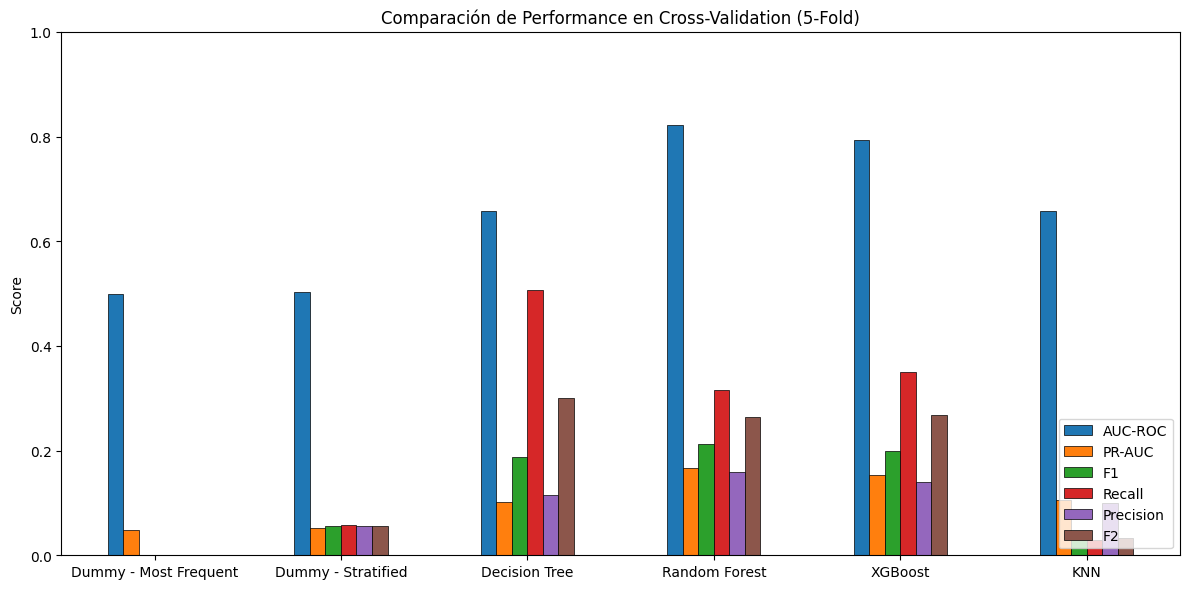

In [11]:
# Tabla resumen de CV
summary_rows = []
for name, scores in cv_results.items():
    row = {'Modelo': name}
    for metric, values in scores.items():
        row[f'{metric} (mean)'] = f"{values.mean():.4f}"
        row[f'{metric} (std)'] = f"{values.std():.4f}"
    summary_rows.append(row)

cv_summary = pd.DataFrame(summary_rows).set_index('Modelo')
display(cv_summary)

# Gráfico de barras
means = pd.DataFrame({
    name: {m: v.mean() for m, v in scores.items()}
    for name, scores in cv_results.items()
}).T

ax = means.plot(kind='bar', figsize=(12, 6), rot=0, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Score')
ax.set_title('Comparación de Performance en Cross-Validation (5-Fold)')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Entrenamiento Final y Evaluación en Test Set

Entrenamos los 4 modelos en todo el training set y evaluamos en test.

In [12]:
# Entrenar modelos finales en todo el training set
trained_models = {}

for name, model in models.items():
    print(f"Entrenando {name}...", end=" ")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print("Listo.")

print("\nTodos los modelos entrenados.")

Entrenando Decision Tree... Listo.
Entrenando Random Forest... Listo.
Entrenando XGBoost... Listo.
Entrenando KNN... Listo.

Todos los modelos entrenados.


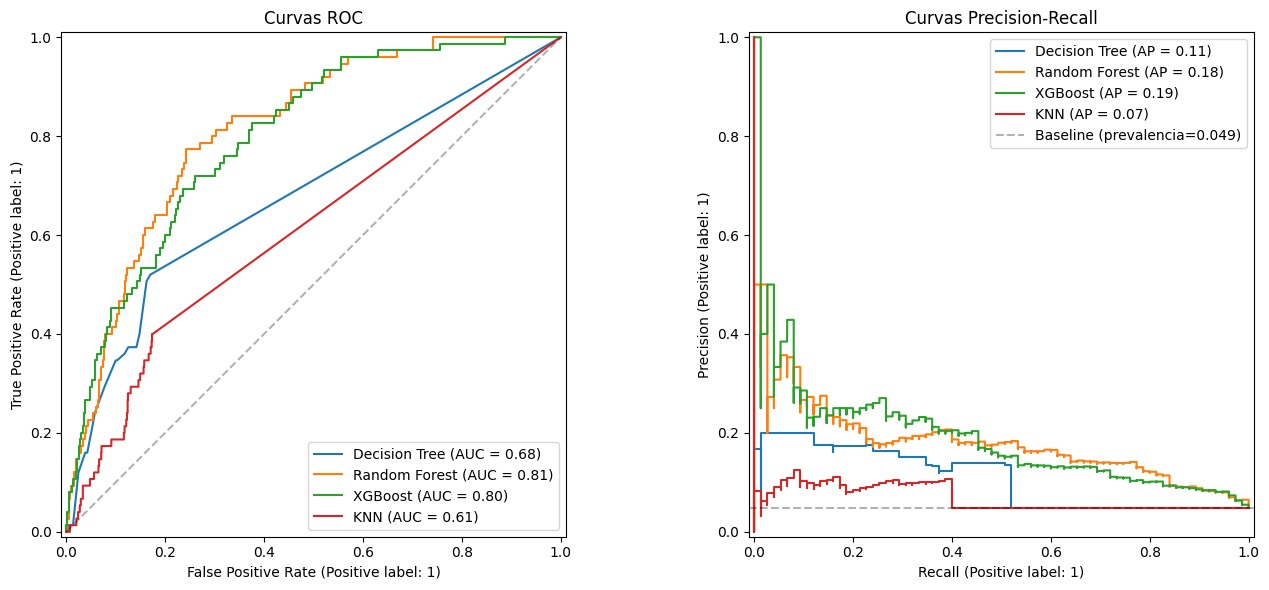

In [13]:
# Curvas ROC y Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, name=name, ax=axes[1])

axes[0].set_title("Curvas ROC")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)

axes[1].set_title("Curvas Precision-Recall")
prevalence = y_test.mean() if hasattr(y_test, 'mean') else np.mean(y_test)
axes[1].axhline(prevalence, color='k', linestyle='--', alpha=0.3,
                label=f'Baseline (prevalencia={prevalence:.3f})')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

In [14]:
# Tabla de métricas en test
test_results = []
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    test_results.append({
        'Modelo': name,
        'AUC-ROC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob),
        'F1': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'F2':        fbeta_score(y_test, y_pred, beta=2),
    })

test_df = pd.DataFrame(test_results).set_index('Modelo')
display(test_df.sort_values('AUC-ROC', ascending=False).style.highlight_max(axis=0))

best_model_name = test_df['AUC-ROC'].idxmax()
print(f"\nMejor modelo por AUC-ROC: {best_model_name} ({test_df.loc[best_model_name, 'AUC-ROC']:.4f})")

,AUC-ROC,PR-AUC,F1,Recall,Precision,F2
Modelo,,,,,,
Random Forest,0.814010,0.181575,0.248000,0.413333,0.177143,0.326316
XGBoost,0.798665,0.191281,0.256604,0.453333,0.178947,0.346939
Decision Tree,0.677714,0.108150,0.215470,0.520000,0.135889,0.332198
KNN,0.608583,0.068253,0.020619,0.013333,0.045455,0.015528



Mejor modelo por AUC-ROC: Random Forest (0.8140)


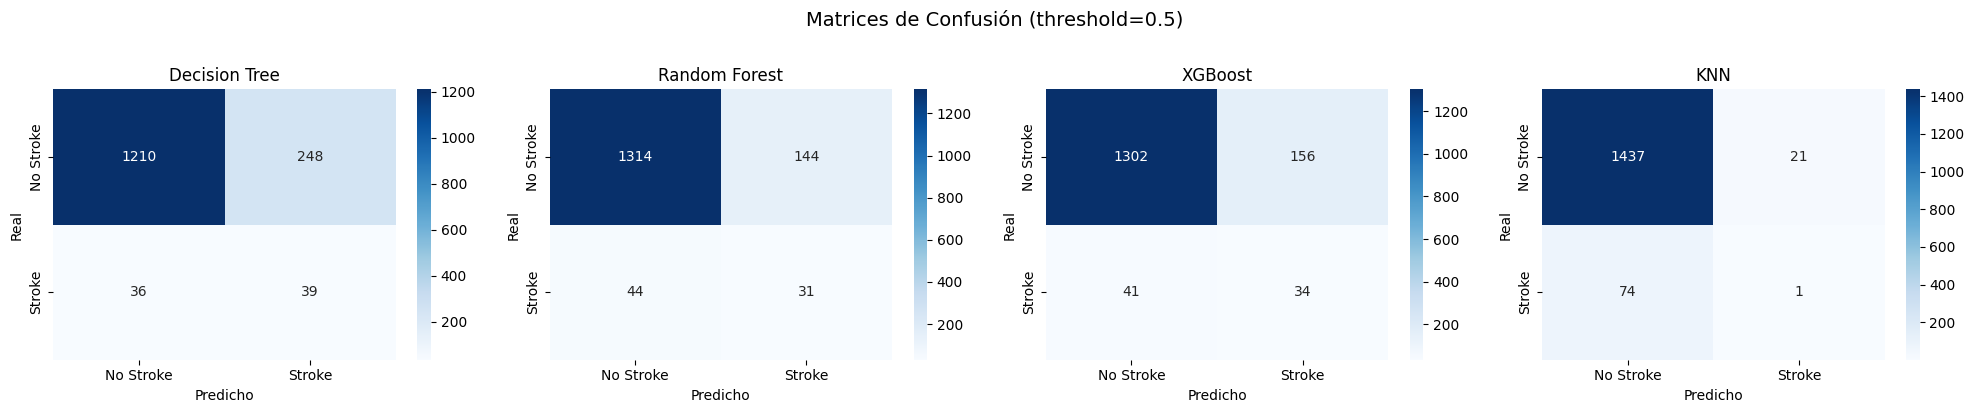

In [15]:
# Matrices de confusión
fig, axes = plt.subplots(1, len(trained_models), figsize=(5 * len(trained_models), 4))

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'])
    axes[i].set_title(name)
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predicho')

plt.suptitle('Matrices de Confusión (threshold=0.5)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
import os
os.makedirs('../models', exist_ok=True)

# Guardar cada modelo entrenado
for name, model in trained_models.items():
    filename = name.lower().replace(' ', '_')
    path = f'../models/{filename}.pkl'
    joblib.dump(model, path)
    print(f"Guardado: {path}")

# Guardar resultados para notebook de evaluación
feature_names = list(X_train.columns) if hasattr(X_train, 'columns') else None

joblib.dump({
    'cv_results': cv_results,
    'test_results': test_df,
    'best_model_name': best_model_name,
    'feature_names': feature_names,
}, '../data/training_results.pkl')

print("\nResultados guardados en ../data/training_results.pkl")
print(f"Mejor modelo: {best_model_name} (AUC-ROC: {test_df.loc[best_model_name, 'AUC-ROC']:.4f})")

Guardado: ../models/decision_tree.pkl
Guardado: ../models/random_forest.pkl
Guardado: ../models/xgboost.pkl
Guardado: ../models/knn.pkl

Resultados guardados en ../data/training_results.pkl
Mejor modelo: Random Forest (AUC-ROC: 0.8140)
